# 01 — Data Pull and Merge

Pull all FRED series, cache locally, resample to monthly, and produce a single clean DataFrame.

**Run this notebook first.** It writes `data/raw/*.csv` and prints sanity checks on coverage and missing values.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.fred_loader import FredLoader

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Pull raw series from FRED

Reads `FRED_API_KEY` from `.env`. Set `force_refresh=True` to re-pull from FRED (otherwise uses local cache).

In [2]:
loader = FredLoader()
print(loader.series_info().to_string(index=False))

series_id                             description
   T10Y2Y            10Y-2Y Spread (daily, 1976+)
   T10Y3M            10Y-3M Spread (daily, 1982+)
    DGS10   10-Year Treasury Yield (daily, 1962+)
     DGS2    2-Year Treasury Yield (daily, 1976+)
     DTB3     3-Month T-Bill Yield (daily, 1954+)
    USREC NBER Recession Indicator (monthly, 0/1)
 FEDFUNDS            Federal Funds Rate (monthly)
   UNRATE             Unemployment Rate (monthly)
 CPIAUCSL                 CPI All Urban (monthly)
    GDPC1                    Real GDP (quarterly)


In [3]:
# Pull all series (uses cache after first run)
raw = loader.pull_all(force_refresh=False)


All 10 series loaded.


## 2. Coverage check on raw series

In [4]:
coverage = pd.DataFrame({
    sid: {
        'first_obs': s.dropna().index.min().date(),
        'last_obs':  s.dropna().index.max().date(),
        'n_obs':     s.dropna().shape[0],
        'freq':      pd.infer_freq(s.dropna().index) or 'mixed',
    }
    for sid, s in raw.items()
}).T

print(coverage.to_string())

           first_obs    last_obs  n_obs    freq
T10Y2Y    1976-06-01  2026-06-23  12511   mixed
T10Y3M    1982-01-04  2026-06-23  11120   mixed
DGS10     1962-01-02  2026-06-22  16102   mixed
DGS2      1976-06-01  2026-06-22  12510   mixed
DTB3      1954-01-04  2026-06-22  18108   mixed
USREC     1954-01-01  2026-05-01    869      MS
FEDFUNDS  1954-07-01  2026-05-01    863      MS
UNRATE    1954-01-01  2026-05-01    868   mixed
CPIAUCSL  1954-01-01  2026-05-01    868   mixed
GDPC1     1954-01-01  2026-01-01    289  QS-OCT


## 3. Build merged monthly DataFrame

In [5]:
df = loader.load_all()
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.tail(6)


All 10 series loaded.
Shape: (870, 15)
Date range: 1954-01-31 to 2026-06-30


,T10Y2Y,T10Y3M,DGS10,DGS2,DTB3,USREC,FEDFUNDS,UNRATE,CPIAUCSL,GDPC1,SPREAD_2S10S_MANUAL,SPREAD_2S10S,SPREAD_10Y3M_MANUAL,SPREAD_10Y3M,SPREAD_10Y3M_EXTENDED
date,,,,,,,,,,,,,,,
2026-01-31,0.676,0.548,4.213,3.537,3.566,0.000,3.640,4.300,326.588,24152.656,0.676,0.676,0.648,0.548,0.548
2026-02-28,0.654,0.438,4.126,3.472,3.602,0.000,3.640,4.400,327.460,NaN,0.654,0.654,0.524,0.438,0.438
2026-03-31,0.531,0.527,4.246,3.715,3.613,0.000,3.640,4.300,330.293,NaN,0.531,0.531,0.633,0.527,0.527
2026-04-30,0.520,0.623,4.319,3.799,3.610,0.000,3.640,4.300,332.407,NaN,0.520,0.520,0.710,0.623,0.623
2026-05-31,0.489,0.798,4.484,3.995,3.599,0.000,3.630,4.300,333.979,NaN,0.489,0.489,0.885,0.798,0.798
2026-06-30,0.376,0.694,4.491,4.113,3.645,NaN,NaN,NaN,NaN,NaN,0.378,0.376,0.847,0.694,0.694


## 4. Missing-value audit

In [6]:
missing = df.isna().sum().rename('nulls')
pct = (df.isna().mean() * 100).rename('null_%').round(1)
first_valid = df.apply(lambda c: c.first_valid_index()).rename('first_valid')

audit = pd.concat([missing, pct, first_valid], axis=1)
print(audit.to_string())

                       nulls  null_% first_valid
T10Y2Y                   269  30.900  1976-06-30
T10Y3M                   336  38.600  1982-01-31
DGS10                     96  11.000  1962-01-31
DGS2                     269  30.900  1976-06-30
DTB3                       0   0.000  1954-01-31
USREC                      1   0.100  1954-01-31
FEDFUNDS                   7   0.800  1954-07-31
UNRATE                     2   0.200  1954-01-31
CPIAUCSL                   2   0.200  1954-01-31
GDPC1                      5   0.600  1954-01-31
SPREAD_2S10S_MANUAL      269  30.900  1976-06-30
SPREAD_2S10S             269  30.900  1976-06-30
SPREAD_10Y3M_MANUAL       96  11.000  1962-01-31
SPREAD_10Y3M              96  11.000  1962-01-31
SPREAD_10Y3M_EXTENDED     96  11.000  1962-01-31


## 5. Sanity checks

- Official spread (`T10Y2Y`) should closely track our manual calculation (`SPREAD_2S10S_MANUAL`) in the overlap period.
- USREC should be 0 or 1 only.
- CPI should be monotonically increasing (it's a price index level).

In [7]:
# Correlation between official and manual 2s10s spread in overlap
overlap = df[['T10Y2Y', 'SPREAD_2S10S_MANUAL']].dropna()
corr = overlap.corr().iloc[0, 1]
diff_max = (overlap['T10Y2Y'] - overlap['SPREAD_2S10S_MANUAL']).abs().max()
print(f'Spread correlation (official vs manual): {corr:.6f}')
print(f'Max absolute difference: {diff_max:.4f} pp')

Spread correlation (official vs manual): 1.000000
Max absolute difference: 0.0024 pp


In [8]:
# USREC should be binary
assert df['USREC'].dropna().isin([0.0, 1.0]).all(), 'USREC contains non-binary values!'
n_rec_months = int(df['USREC'].sum())
print(f'USREC: {n_rec_months} recession months out of {df["USREC"].notna().sum()} total')

USREC: 108 recession months out of 869 total


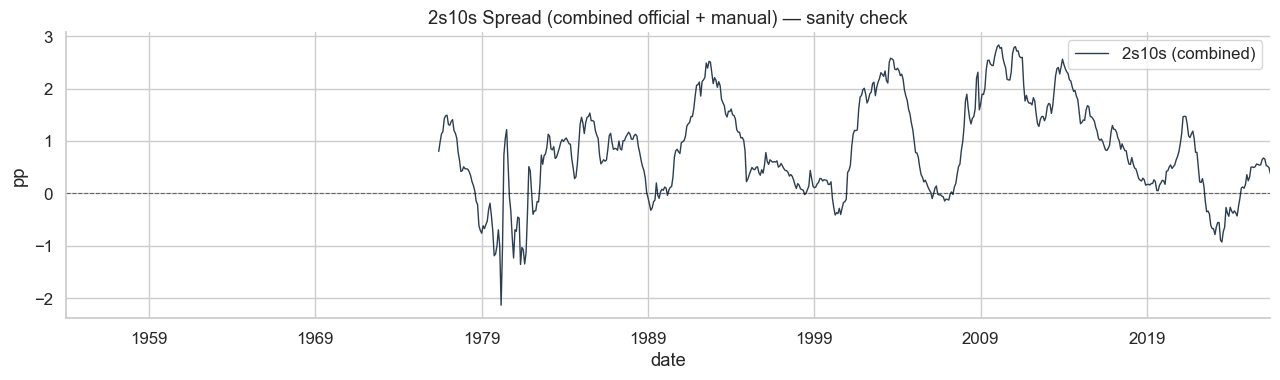

In [9]:
# Quick plot: verify the combined spread looks right
fig, ax = plt.subplots(figsize=(13, 4))
df['SPREAD_2S10S'].plot(ax=ax, color='#2c3e50', linewidth=1.0, label='2s10s (combined)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('2s10s Spread (combined official + manual) — sanity check')
ax.legend()
ax.set_ylabel('pp')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 6. Save merged data

Write the cleaned monthly DataFrame to `data/raw/merged_monthly.csv` for downstream notebooks.

In [10]:
out_path = '../data/raw/merged_monthly.csv'
df.to_csv(out_path)
print(f'Saved to {out_path}')
print(f'Columns: {list(df.columns)}')

Saved to ../data/raw/merged_monthly.csv
Columns: ['T10Y2Y', 'T10Y3M', 'DGS10', 'DGS2', 'DTB3', 'USREC', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'SPREAD_2S10S_MANUAL', 'SPREAD_2S10S', 'SPREAD_10Y3M_MANUAL', 'SPREAD_10Y3M', 'SPREAD_10Y3M_EXTENDED']
